In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/My Drive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


**Data Preparation**

In [2]:
import pandas as pd
df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
df.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [4]:
df.drop(columns='transaction_id', inplace=True)
df.head(5)

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [5]:
df['velocity_last_24h'].unique()

array([3, 1, 0, 2, 4, 7, 5, 6, 8, 9])

In [6]:
df.isnull().sum()

,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [7]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [8]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [9]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [10]:
df['transaction_hour'].unique()

array([22,  3, 17,  4, 15, 13, 18,  8,  5, 16, 11, 10, 21,  7,  1, 23, 20,
        9,  6, 12,  0, 19,  2, 14])

In [11]:
import numpy as np

#Cyclical Encoding
df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour'] /24)
df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour'] /24)

In [12]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data latih {len(X_train)} dan jumlah data uji {len(X_test)}")

Jumlah data latih 8000 dan jumlah data uji 2000


**Preprocessing**

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [15]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder='passthrough')

In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model_baseline = LogisticRegression(random_state=42)

**Model Baseline**

In [17]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', logistic_model_baseline)
])

In [18]:
baseline_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', LogisticRegression(random_state=42))])

In [19]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Hasil akurasi dengan data uji :{accuracy_baseline:.4f}")
print(classification_report(y_test, y_pred_baseline))

Hasil akurasi dengan data uji :0.9895
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1970
           1       0.71      0.50      0.59        30

    accuracy                           0.99      2000
   macro avg       0.85      0.75      0.79      2000
weighted avg       0.99      0.99      0.99      2000



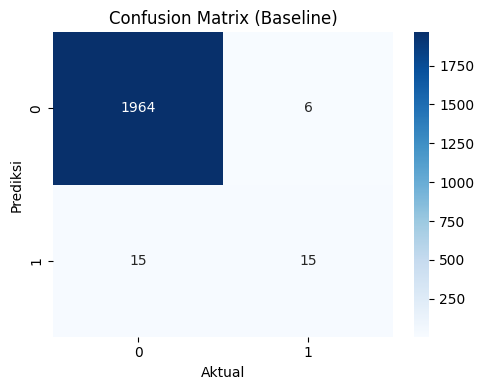

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout(),
plt.show()

In [22]:
from sklearn.metrics import roc_auc_score

y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(roc_auc_baseline)

0.9945685279187817


**LogisticRegression + Class Weight**

In [23]:
logistic_model_balanced = LogisticRegression(random_state=42,class_weight='balanced')

In [24]:
balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', logistic_model_balanced)
])

In [25]:
balanced_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [26]:
y_pred_balanced = balanced_pipeline.predict(X_test)

In [27]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"Hasil akurasi dengan data uji :{accuracy_balanced:.4f}")
print(classification_report(y_test, y_pred_balanced))

Hasil akurasi dengan data uji :0.9520
              precision    recall  f1-score   support

           0       1.00      0.95      0.98      1970
           1       0.24      1.00      0.38        30

    accuracy                           0.95      2000
   macro avg       0.62      0.98      0.68      2000
weighted avg       0.99      0.95      0.97      2000



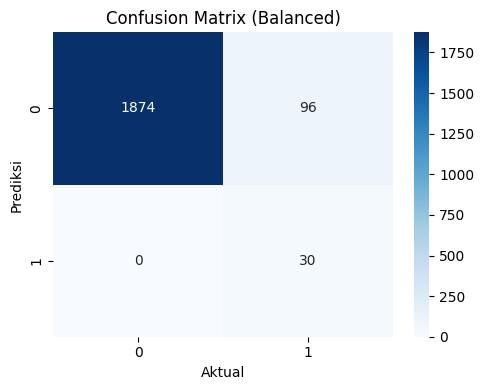

In [28]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(5,4))
sns.heatmap(cm_balanced, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix (Balanced)')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout()
plt.show()

In [29]:
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:,1]
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)
print(roc_auc_balanced)

0.9932656514382403


**LogisticRegression + SMOTE**

In [30]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', logistic_model_baseline)
])

In [31]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(random_state=42))])

In [32]:
y_pred_smote = smote_pipeline.predict(X_test)

In [33]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print(f"Hasil akurasi dengan data uji :{accuracy_smote:.4f}")
print(classification_report(y_test, y_pred_smote))

Hasil akurasi dengan data uji :0.9600
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.27      1.00      0.43        30

    accuracy                           0.96      2000
   macro avg       0.64      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000



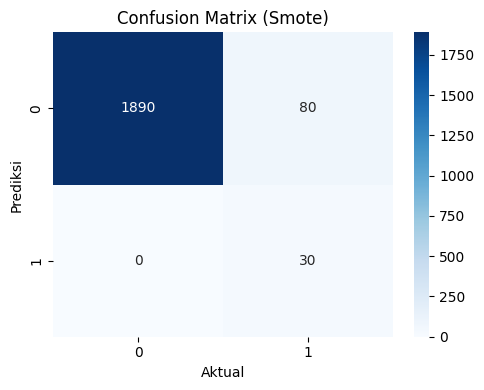

In [34]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix (Smote)')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout()
plt.show()

In [35]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(roc_auc_smote)

0.9932656514382403


**Model Hyperparameter Tuning Menggunakan SMOTE**

In [36]:
params_grid = [
    {
        'model__penalty': ['l1','l2'],
        'model__C' : [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear'],
        'model__max_iter' : [1000, 2000]
    },
    {
        'model__penalty' : ['l2'],
        'model__C' : [0.01, 0.1, 1, 10, 100],
        'model__solver' : ['lbfgs','newton-cg'],
        'model__max_iter' : [1000, 2000]
    }
]

In [37]:
from sklearn.model_selection import GridSearchCV

GridSearchLR = GridSearchCV(
    estimator = smote_pipeline,
    param_grid=params_grid,
    cv = 5,
    scoring = 'f1',
    verbose = 2,
    n_jobs = -1
)

In [38]:
GridSearchLR.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__C': [0.01, 0.1, 1, 10, 100],
                          'model__max_iter': [1000, 2000],
                          'model__penalty': ['l1', 'l2'],
                          'model__solver': ['liblinear']},
                         {'model__C': [0.01, 0.1, 1, 10, 100],
                          'model__max_iter': [1000, 2000],
                          'model__penalty': ['l2'],
                          'model__solver': ['lbfgs', 'newton-cg']}],
             scoring='f1', verbose=2)

In [39]:
print(GridSearchLR.best_params_)

{'model__C': 10, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [40]:
best_logistic = GridSearchLR.best_estimator_

In [41]:
print("Best params yang ditemukan: ", GridSearchLR.best_params_)
print("Best CV Score yang ditemukan: ", GridSearchLR.best_score_)

Best params yang ditemukan:  {'model__C': 10, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV Score yang ditemukan:  0.4324001924001924


In [42]:
y_pred = best_logistic.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Hasil akurasi dengan data uji :{accuracy:.4f}")
print(classification_report(y_test, y_pred))

Hasil akurasi dengan data uji :0.9620
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.28      1.00      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.98      0.71      2000
weighted avg       0.99      0.96      0.97      2000



In [44]:
y_prob = best_logistic.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test,y_pred))

ROC AUC: 0.9931641285956007
[[1894   76]
 [   0   30]]


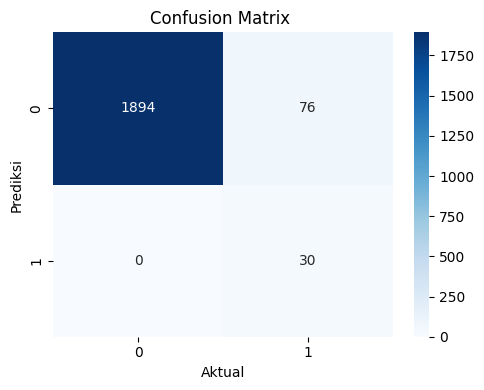

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix ')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout(),
plt.show()

In [48]:
features_names = best_logistic.named_steps['preprocessor'].get_feature_names_out()
print(features_names)

['num__amount' 'num__device_trust_score' 'num__velocity_last_24h'
 'num__cardholder_age' 'remainder__hour_sin' 'remainder__hour_cos'
 'remainder__foreign_transaction' 'remainder__location_mismatch']


In [53]:
coef = best_logistic.named_steps['model'].coef_[0]
for fitur, nilai in zip (features_names,coef):
  print(f"{fitur}: {nilai:.4f}")

num__amount: 1.0943
num__device_trust_score: -3.6089
num__velocity_last_24h: 2.3149
num__cardholder_age: -0.5703
remainder__hour_sin: 1.8457
remainder__hour_cos: 4.9691
remainder__foreign_transaction: 7.2130
remainder__location_mismatch: 7.3859


In [56]:
coef_df = pd.DataFrame({
    'Feature': features_names,
    'Coefficient': coef
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

coef_df

,Feature,Coefficient,Abs_Coefficient
7,remainder__location_mismatch,7.385893,7.385893
6,remainder__foreign_transaction,7.213038,7.213038
5,remainder__hour_cos,4.969146,4.969146
1,num__device_trust_score,-3.608857,3.608857
2,num__velocity_last_24h,2.314946,2.314946
4,remainder__hour_sin,1.845743,1.845743
0,num__amount,1.094300,1.094300
3,num__cardholder_age,-0.570276,0.570276


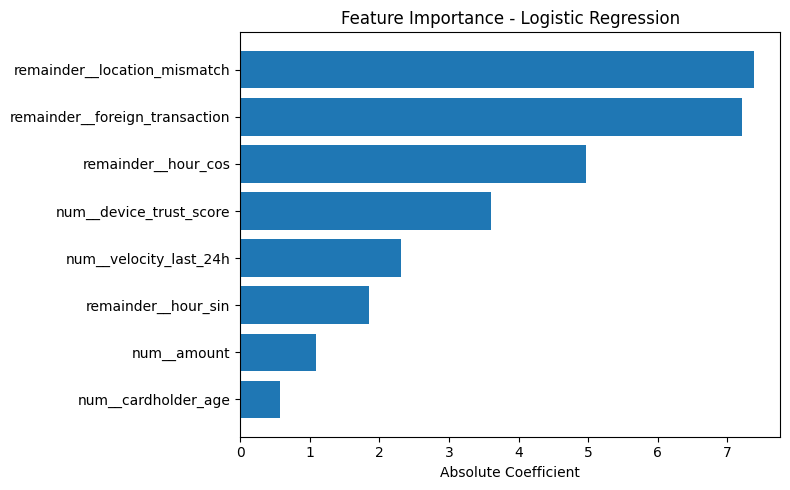

In [57]:
coef_plot = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    coef_plot['Feature'],
    coef_plot['Abs_Coefficient']
)

plt.xlabel("Absolute Coefficient")
plt.title("Feature Importance - Logistic Regression")

plt.tight_layout()
plt.show()